# 2. Periodic

In this notebook we show that tensor decoupling can be used with more complex functions than low-degree polynomials.

Let's define a periodic multivariate function.

In [1]:
import jax, jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme('notebook', 'white', palette='dark')

key = jax.random.key(42)
key_test = jax.random.key(43)

def target(x):
    x1, x2 = x
    return jnp.array([
        jnp.cos(3*jnp.pi*x1) + jnp.cos(jnp.pi*x2),
        2*jnp.sin(2*jnp.pi*x2) - jnp.sin(jnp.pi*x1),
    ])

We can plot each output for $x_1 = x_2$, to get a rough idea of the shape of this function.

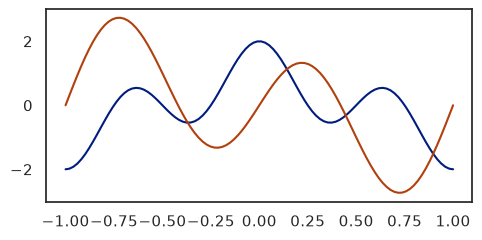

In [2]:
x = jnp.linspace(-1, 1, 100)
X = jnp.stack([x, x], axis=1)
Y = jax.vmap(target)(X)

plt.figure(figsize=(5.5, 2.5))
plt.plot(x, Y[:, 0])
plt.plot(x, Y[:, 1])
plt.show(); plt.close()

Let's see how our decoupling approach performs on that one.

Again, we first need to collect information about the target.

In [3]:
from decoupling.utils import collect_information_from_random

N = 100

info = collect_information_from_random(target, N, 2, key, minval=-1.1, maxval=1.1)

X_test, _, _ = collect_information_from_random(target, N, 2, key_test, minval=-1.0, maxval=1.0)
# it is often better to sample slightly out of the range of interest (here [-1, 1]),
# to get a better curve near the boundaries

info[2].shape

(2, 2, 100)

In [4]:
from decoupling import Algorithm

rank = 4

algorithm = Algorithm(rank, key, niters=50, ninits=3, splines_dof=25)
decoupling = algorithm.run(*info)

print(f'CPD-Error: {algorithm.info.errors.min():.4f}')

[Seed 3/3]: 100%|██████████████████████████████| 50/50 [00:00<00:00, 152.27it/s, error=0.0274, best=0.0269 (47), rcond=2.4e-01]


CPD-Error: 0.0249


In [5]:
from decoupling.utils import function_error_from_callable

err1, err2 = function_error_from_callable(target, decoupling, X_test)
print(f'Error(y1)={err1:.2f}, Error(y2)={err2:.2f}')

Error(y1)=3.48, Error(y2)=1.31


Both tensor and functions errors are quite low, indicating that our method managed to find a decent approximation of the target.

Lets plot the outputs to see if they match.

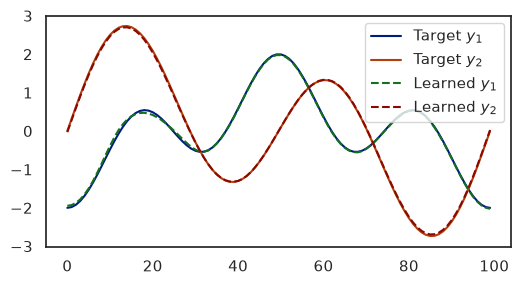

In [6]:
Ytarget = jax.vmap(target)(X)
Ylearned = jax.vmap(decoupling)(X)

plt.figure(figsize=(6, 3))
plt.plot(Ytarget[:, 0], label='Target $y_1$')
plt.plot(Ytarget[:, 1], label='Target $y_2$')
plt.plot(Ylearned[:, 0], label='Learned $y_1$', linestyle='--')
plt.plot(Ylearned[:, 1], label='Learned $y_2$', linestyle='--')
plt.legend(); plt.show(); plt.close()

That looks very good, the curves overlap almost perfectly!

Again, to get some insights about our target, we can look at the shapes of the internals of the returned decoupled model.

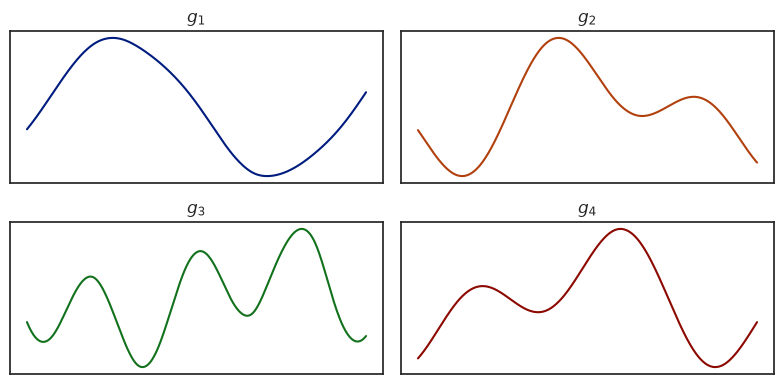

In [7]:
colors = sns.color_palette()

Z = info[0] @ decoupling.V
minmax = [(Z[:, r].min(), Z[:, r].max()) for r in range(rank)]

inputs = jnp.stack([jnp.linspace(lo, hi, 500) for (lo, hi) in minmax], axis=1)
outputs = jax.vmap(decoupling.internals)(inputs)

fig, ax = plt.subplots(2, 2, figsize=(8, 4))

for r, a in enumerate(ax.flatten()): 
    a.set_xticks([]); a.set_yticks([])
    idx = jnp.argsort(Z[:, r])
    a.plot(inputs[:, r], outputs[:, r], color=colors[r])
    a.set_title(f'$g_{r+1}$')

plt.tight_layout(); plt.show()